In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from matplotlib import cm

from sklearn.decomposition import PCA
from sklearn.manifold import MDS
from sklearn.manifold import TSNE

from matplotlib.lines import Line2D


RANDOM_SEED = 239

In [2]:
data = pd.read_csv("samples_filtered.counts", sep="\t", header=0, index_col=0)
meta = pd.read_csv("metadata.tsv", header=0, index_col=0, sep="\t")

In [3]:
data = data.div(data.sum(axis=1), axis=0)
data

,ENSG00000000003.16,ENSG00000000005.6,ENSG00000000419.14,ENSG00000000457.14,ENSG00000000460.17,ENSG00000000938.13,ENSG00000000971.17,ENSG00000001036.14,ENSG00000001084.13,ENSG00000001167.15,...,ENSG00000310523.1,ENSG00000310525.1,ENSG00000310526.1,ENSG00000310527.1,ENSG00000310528.1,ENSG00000310529.1,ENSG00000310532.2,ENSG00000310533.1,ENSG00000310537.1,ENSG00000310539.1
Po4S_7_11_2022_1_EKDL220017801-1A_HKLKJDSX5_L3,0.000093,4.444970e-08,0.000032,0.000023,0.000029,3.111479e-07,0.000000e+00,0.000047,0.000035,0.000082,...,0.000007,8.889941e-08,0.000004,0.000005,0.000000e+00,0.000000e+00,0.000000e+00,3.111479e-07,4.444970e-08,8.889941e-08
Po4S_7_11_2022_1_EKDL220017801-1A_HMNK7DSX5_L4,0.000089,2.251895e-07,0.000032,0.000027,0.000031,7.506316e-07,0.000000e+00,0.000046,0.000037,0.000083,...,0.000008,0.000000e+00,0.000005,0.000007,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,7.506316e-08
Po4S_7_11_2022_2_EKDL220017801-1A_HKLKJDSX5_L3,0.000086,3.620071e-07,0.000033,0.000024,0.000032,1.086021e-07,0.000000e+00,0.000043,0.000031,0.000080,...,0.000006,3.620071e-08,0.000004,0.000008,0.000000e+00,0.000000e+00,0.000000e+00,3.982078e-07,3.620071e-08,1.086021e-07
Po4S_7_11_2022_2_EKDL220017801-1A_HMNK7DSX5_L4,0.000095,6.088260e-08,0.000032,0.000025,0.000031,2.435304e-07,0.000000e+00,0.000044,0.000035,0.000075,...,0.000008,6.088260e-08,0.000005,0.000006,0.000000e+00,0.000000e+00,0.000000e+00,2.435304e-07,1.217652e-07,6.088260e-08
FF9S_7_11_2022_1_EKDL220017801-1A_HKLKJDSX5_L3,0.000072,0.000000e+00,0.000028,0.000015,0.000010,7.284515e-07,9.105644e-08,0.000028,0.000038,0.000065,...,0.000010,4.552822e-08,0.000007,0.000008,9.105644e-08,0.000000e+00,0.000000e+00,1.821129e-07,0.000000e+00,9.105644e-08
FF9S_7_11_2022_1_EKDL220017801-1A_HMNK7DSX5_L4,0.000069,0.000000e+00,0.000027,0.000013,0.000009,3.060094e-07,7.650236e-08,0.000026,0.000034,0.000060,...,0.000011,0.000000e+00,0.000006,0.000010,0.000000e+00,0.000000e+00,0.000000e+00,2.295071e-07,0.000000e+00,1.530047e-07
FF9S_7_11_2022_2_EKDL220017801-1A_HKLKJDSX5_L3,0.000089,0.000000e+00,0.000030,0.000020,0.000015,3.865667e-07,0.000000e+00,0.000034,0.000033,0.000075,...,0.000009,1.449625e-07,0.000006,0.000009,0.000000e+00,0.000000e+00,0.000000e+00,3.382458e-07,1.449625e-07,9.664166e-08
FF9S_7_11_2022_2_EKDL220017801-1A_HMNK7DSX5_L4,0.000091,0.000000e+00,0.000032,0.000017,0.000018,8.142311e-08,0.000000e+00,0.000033,0.000035,0.000074,...,0.000008,0.000000e+00,0.000006,0.000010,0.000000e+00,0.000000e+00,8.142311e-08,8.142311e-08,0.000000e+00,8.142311e-08
BL6S_7_11_2022_1_EKDL220017801-1A_HKLKJDSX5_L3,0.000087,0.000000e+00,0.000027,0.000016,0.000015,2.150811e-07,0.000000e+00,0.000027,0.000026,0.000099,...,0.000012,4.301622e-08,0.000010,0.000010,0.000000e+00,0.000000e+00,4.301622e-08,2.150811e-07,0.000000e+00,4.301622e-08
BL6S_7_11_2022_1_EKDL220017801-1A_HMNK7DSX5_L4,0.000082,0.000000e+00,0.000023,0.000016,0.000016,2.890091e-07,0.000000e+00,0.000025,0.000026,0.000095,...,0.000011,0.000000e+00,0.000008,0.000008,0.000000e+00,7.225228e-08,0.000000e+00,1.445046e-07,0.000000e+00,2.167568e-07


In [4]:
meta

,Tech.rep,Health.PD,Ergicity,Cells.Msc.SPb,Mutation,Lab.name,Pub.name,pict.name
ID,,,,,,,,
Po4S_7_11_2022_1_EKDL220017801-1A_HKLKJDSX5_L3,1,H,DA,SPb,NO,Po4S,RG4S,Health_1
Po4S_7_11_2022_1_EKDL220017801-1A_HMNK7DSX5_L4,1,H,DA,SPb,NO,Po4S,RG4S,Health_1
Po4S_7_11_2022_2_EKDL220017801-1A_HKLKJDSX5_L3,2,H,DA,SPb,NO,Po4S,RG4S,Health_1
Po4S_7_11_2022_2_EKDL220017801-1A_HMNK7DSX5_L4,2,H,DA,SPb,NO,Po4S,RG4S,Health_1
FF9S_7_11_2022_1_EKDL220017801-1A_HKLKJDSX5_L3,1,H,DA,SPb,NO,FF9S,FF9S,Health_2
FF9S_7_11_2022_1_EKDL220017801-1A_HMNK7DSX5_L4,1,H,DA,SPb,NO,FF9S,FF9S,Health_2
FF9S_7_11_2022_2_EKDL220017801-1A_HKLKJDSX5_L3,2,H,DA,SPb,NO,FF9S,FF9S,Health_2
FF9S_7_11_2022_2_EKDL220017801-1A_HMNK7DSX5_L4,2,H,DA,SPb,NO,FF9S,FF9S,Health_2
BL6S_7_11_2022_1_EKDL220017801-1A_HKLKJDSX5_L3,1,PD,DA,SPb,LRRK2,Bl6S,PDL1.6S,LRRK2_1


Text(0.5, 1.0, 'PCA')

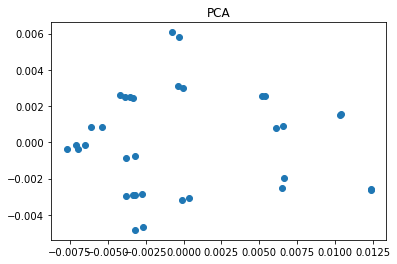

In [5]:
pca = PCA(n_components=2, random_state=RANDOM_SEED)
data_pca = pca.fit_transform(data)
#print(data_pca)
plt.scatter(data_pca[:, 0], data_pca[:, 1])
plt.title("PCA")

Text(0.5, 1.0, 'MDS euclidean')

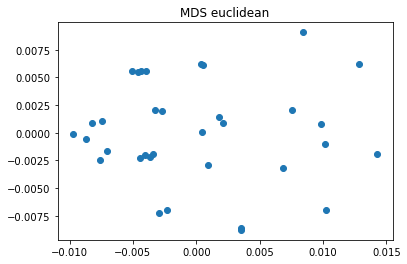

In [6]:
mds = MDS(n_components=2, metric=True, random_state=RANDOM_SEED)
data_mds = mds.fit_transform(data)
plt.scatter(data_mds[:, 0], data_mds[:, 1])
plt.title("MDS euclidean")

Text(0.5, 1.0, 't-SNE bray-curtis')

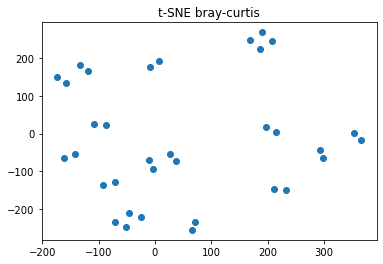

In [7]:
tsne = TSNE(n_components=2, perplexity=4, metric='braycurtis', random_state=RANDOM_SEED)
data_tsne = tsne.fit_transform(data)
plt.scatter(data_tsne[:, 0], data_tsne[:, 1])
plt.title("t-SNE bray-curtis")

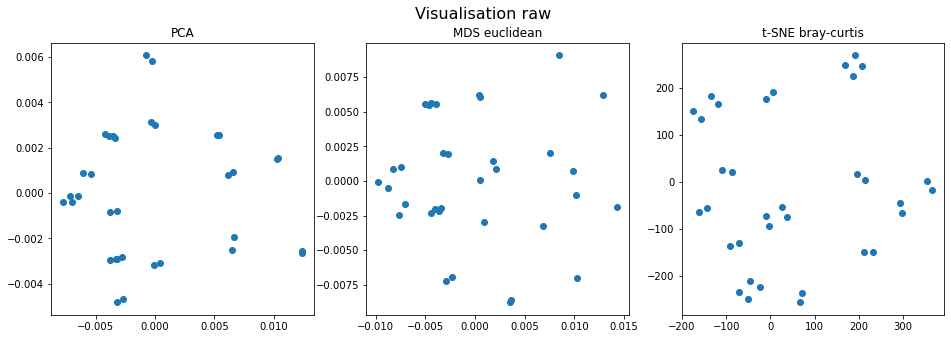

In [8]:
fig = plt.figure(figsize=(16, 5))

ax1 = plt.subplot(1, 3, 1)
ax1.scatter(data_pca[:, 0], data_pca[:, 1])
plt.title("PCA")

ax2 = plt.subplot(1, 3, 2)
ax2.scatter(data_mds[:, 0], data_mds[:, 1])
plt.title("MDS euclidean")

ax3 = plt.subplot(1, 3, 3)
ax3.scatter(data_tsne[:, 0], data_tsne[:, 1])
plt.title("t-SNE bray-curtis")

fig.suptitle("Visualisation raw", fontsize=16)
plt.show()

In [9]:
def get_line(color):
    return Line2D([0], [0], marker='o', markerfacecolor=color, markeredgecolor=color, c='w')

def draw(params={}, name="Visualisation raw", legend={}):
    fig = plt.figure(figsize=(16, 5))

    ax1 = plt.subplot(1, 3, 1)
    ax1.scatter(data_pca[:, 0], data_pca[:, 1], **params)
    plt.title("PCA")

    ax2 = plt.subplot(1, 3, 2)
    ax2.scatter(data_mds[:, 0], data_mds[:, 1], **params)
    plt.title("MDS euclidean")

    ax3 = plt.subplot(1, 3, 3)
    ax3.scatter(data_tsne[:, 0], data_tsne[:, 1], **params)
    plt.title("t-SNE bray-curtis")
    
    
    custom_lines = [get_line(color) for color in legend.values()]
    fig.legend(custom_lines, legend.keys())

    fig.suptitle(name, fontsize=16)
    plt.show()

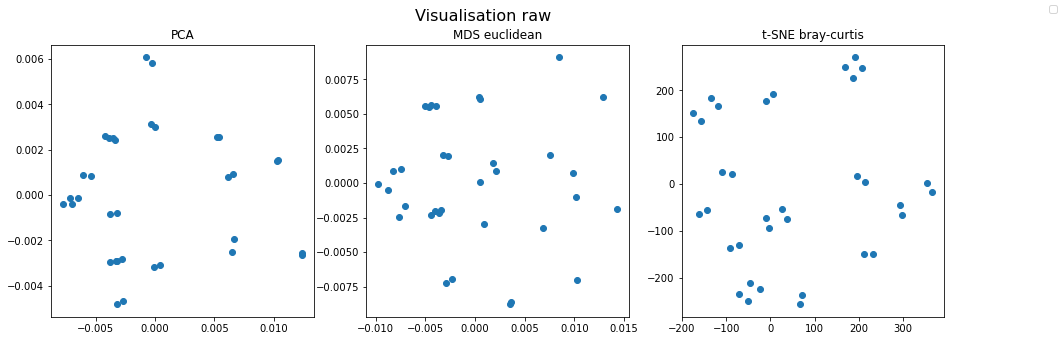

In [10]:
draw()

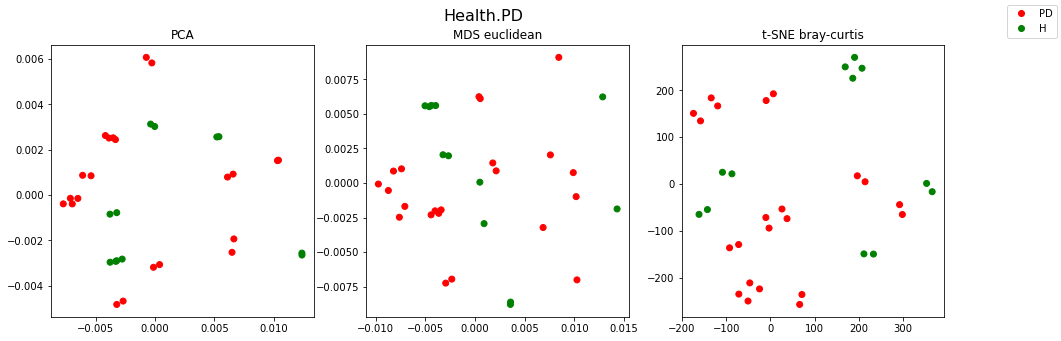

In [11]:
# HEALTH.PD
legend = {'PD':'r', 'H':'g'}
params = {'c':[legend[i] for i in meta["Health.PD"]]}
draw(params, "Health.PD", legend)

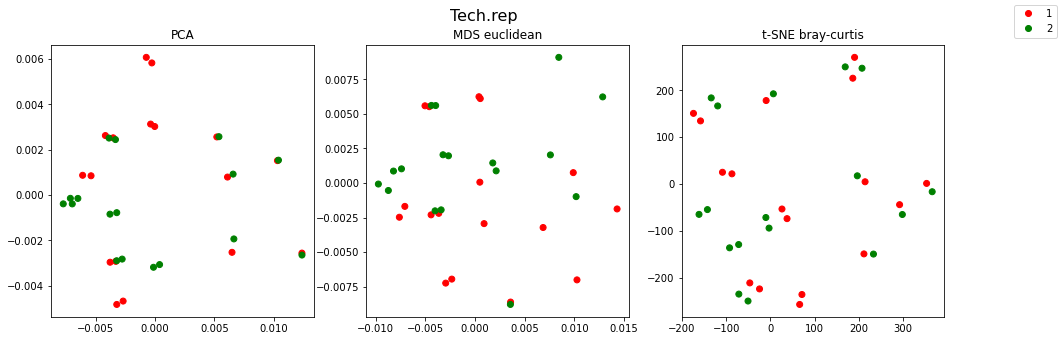

In [12]:
# Tech.rep
legend = {1:'r', 2:'g'}
params = {'c':[legend[i] for i in meta["Tech.rep"]]}
draw(params, "Tech.rep", legend)

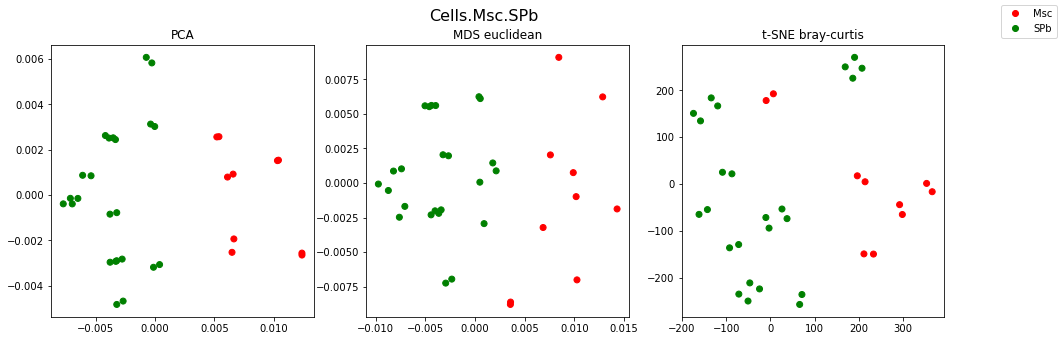

In [13]:
# Cells.Msc.SPb
legend = {'Msc':'r', 'SPb':'g'}
params = {'c':[legend[i] for i in meta["Cells.Msc.SPb"]]}
draw(params, "Cells.Msc.SPb", legend)

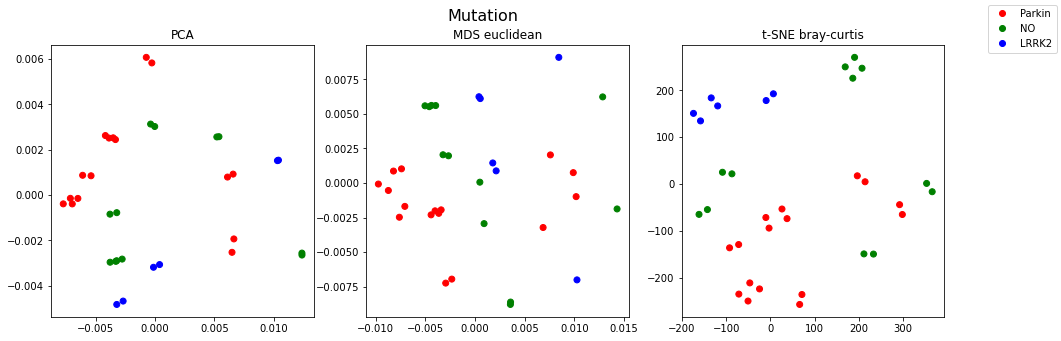

In [14]:
# Mutation
legend = {'Parkin':'r', 'NO':'g', 'LRRK2':'b'}
params = {'c':[legend[i] for i in meta["Mutation"]]}
draw(params, "Mutation", legend)

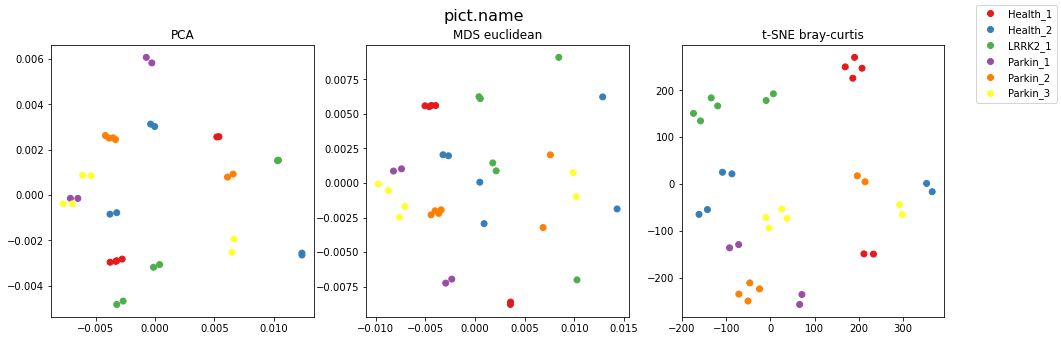

In [22]:
# pict.name
legend = dict(zip(np.unique(meta["pict.name"]), cm.get_cmap('Set1').colors))
params = {'c':[legend[i] for i in meta["pict.name"]]}
draw(params, "pict.name", legend)